# RQ4b — RQ4 re-run with `change_perc_train` recovered from the logs

**Why this notebook exists.** 42 rows of `results.csv` carry `best_patch_fitness_train = NaN`
and `change_perc_train = 0.0` even though the run *did* find, write and validate a real patch
(the `.patch` file exists on disk and `validate_log` is present). They are concentrated in the
LLM-guided groups:

| group | corrupted rows (of 100) |
|---|---|
| LLM-llama3.1:8b | 27 |
| LLM-qwen2.5-coder:7b | 13 |
| UMDA+qwen2.5-coder:7b | 2 |
| UMDA4GI | 0 |
| UMDA+llama3.1:8b | 0 |

`RQ4.ipynb` computes `overfit = change_perc_validate - change_perc_train` over **every** row
without filtering, so a spurious train value of `0.0` understates the generalisation gap of
exactly those groups (a run that improved training by 21% is recorded as having improved it by 0%,
making the validate-vs-train gap look far smaller than it is).

**What this notebook does.** It recovers the true training fitness from the MAGPIE logs
(`recover_train_fitness.py`, validated to reproduce the CSV value *exactly* on all 886 rows where
the CSV value is present), then re-runs the RQ4 analysis **twice** — once with the original data
and once with the corrected data — and reports both side by side.

Everything else (grouping, aggregation, ranking) is copied verbatim from `RQ4.ipynb`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

sys.path.insert(0, os.getcwd())
import recover_train_fitness as rec

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

# --- recover the true train fitness from the logs -------------------------------
recovered = rec.recover(df_all)
v = rec.validate(recovered)
print('Validation of the recovery method on rows where the CSV value is present:')
print(f"  rows checked                     : {v['rows_with_csv_value']}")
print(f"  best fitness exact match         : {v['best_fitness_exact_match']}")
print(f"  change_perc_train within 0.001   : {v['change_perc_within_tol']}")
assert v['best_fitness_exact_match'] == v['rows_with_csv_value'], 'recovery does not reproduce known values'

Validation of the recovery method on rows where the CSV value is present:
  rows checked                     : 757
  best fitness exact match         : 757
  change_perc_train within 0.001   : 757


In [2]:
# Rows that RQ4 silently treats as change_perc_train = 0
corrupt_mask = df_all['best_patch_fitness_train'].isna() & df_all['validate_log'].notna()
print(f'Corrupted rows: {int(corrupt_mask.sum())}')

comp = recovered.loc[corrupt_mask, ['software', 'algorithm', 'llm_model',
                                    'change_perc_train', 'recovered_change_perc_train']]
print('\nchange_perc_train: what RQ4 used (0.0) vs what the logs actually say')
print(comp.groupby([comp['algorithm'], comp['llm_model'].fillna('none')])
        ['recovered_change_perc_train'].describe()[['count', 'mean', 'min', 'max']].round(2).to_string())

Corrupted rows: 42

change_perc_train: what RQ4 used (0.0) vs what the logs actually say
                                count   mean    min   max
algorithm     llm_model                                  
LLMAlgorithm  llama3.1:8b        27.0 -21.20 -97.76 -1.55
              qwen2.5-coder:7b   13.0 -28.78 -97.51 -0.21
UMDAAlgorithm qwen2.5-coder:7b    2.0  -7.07 -12.07 -2.07


In [3]:
# --- RQ4 setup, verbatim from RQ4.ipynb -----------------------------------------
MODELS_KEEP = {'llama3.1:8b', 'qwen2.5-coder:7b'}

GROUP_ORDER = [
    'UMDA4GI',
    'UMDA+llama3.1:8b',
    'UMDA+qwen2.5-coder:7b',
    'LLM-llama3.1:8b',
    'LLM-qwen2.5-coder:7b',
]
software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j': 'Sat4J',
    'weka': 'Weka',
    'pngOptim': 'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']
FIXED_COLORS = {
    'UMDA4GI':                 cm.tab10(3),
    'UMDA+llama3.1:8b':        cm.tab10(4),
    'UMDA+qwen2.5-coder:7b':   cm.tab10(5),
    'LLM-llama3.1:8b':         cm.tab10(6),
    'LLM-qwen2.5-coder:7b':    cm.tab10(7),
}
color_map = {g: FIXED_COLORS[g] for g in GROUP_ORDER}


def assign_group(row):
    alg, llm = row['algorithm'], row['llm_model']
    if alg == 'UMDAAlgorithm' and pd.isna(llm):              return 'UMDA4GI'
    if alg == 'UMDAAlgorithm' and llm == 'llama3.1:8b':      return 'UMDA+llama3.1:8b'
    if alg == 'UMDAAlgorithm' and llm == 'qwen2.5-coder:7b': return 'UMDA+qwen2.5-coder:7b'
    if alg == 'LLMAlgorithm'  and llm == 'llama3.1:8b':      return 'LLM-llama3.1:8b'
    if alg == 'LLMAlgorithm'  and llm == 'qwen2.5-coder:7b': return 'LLM-qwen2.5-coder:7b'
    return None


def prepare(source, corrected):
    '''Reproduce RQ4.ipynb's df. If corrected, replace change_perc_train on the 42 rows.'''
    d = source[
        (source['fitness'] == 'Perf<Cycles>') &
        (source['algorithm'].isin(['UMDAAlgorithm', 'LLMAlgorithm'])) &
        (source['llm_model'].isna() | source['llm_model'].isin(MODELS_KEEP))
    ].copy()
    for col in ['change_perc_validate', 'change_perc_train', 'max_evals']:
        d[col] = pd.to_numeric(d[col], errors='coerce')
    d['max_evals'] = d['max_evals'].astype(int)
    if corrected:
        fix = d['best_patch_fitness_train'].isna() & d['validate_log'].notna()
        d.loc[fix, 'change_perc_train'] = d.loc[fix, 'recovered_change_perc_train']
        print(f'  corrected {int(fix.sum())} rows')
    d['group'] = d.apply(assign_group, axis=1)
    d = d[d['group'].notna()]
    d['overfit'] = d['change_perc_validate'] - d['change_perc_train']
    return d


print('ORIGINAL (as RQ4.ipynb):')
df_orig = prepare(recovered, corrected=False)
print(f'  rows: {len(df_orig)}')
print('CORRECTED:')
df_corr = prepare(recovered, corrected=True)
print(f'  rows: {len(df_corr)}')

ORIGINAL (as RQ4.ipynb):
  rows: 500
CORRECTED:
  corrected 42 rows
  rows: 500


In [4]:
# --- aggregation + rankings, verbatim logic from RQ4.ipynb cells 2, 8 and 10 -----
group_cols = ['software', 'group', 'max_evals']


def aggregate(d):
    agg = (
        d.groupby(group_cols, as_index=False)
         .agg(
             change_perc_validate=('change_perc_validate', 'median'),
             change_perc_train   =('change_perc_train',    'median'),
             overfit             =('overfit',              'median'),
             cpv_std             =('change_perc_validate', 'std'),
             n_folds             =('fold',                 'count'),
         )
    )
    agg['group'] = pd.Categorical(agg['group'], categories=GROUP_ORDER, ordered=True)
    return agg.sort_values(['software', 'group', 'max_evals'])


def ranking(agg, metric):
    '''RQ4 recipe: median per budget (already in agg), mean across budgets, rank per software.'''
    per_sw = agg.groupby(['software', 'group'], as_index=False, observed=True)[metric].mean()
    per_sw['rank'] = per_sw.groupby('software')[metric].rank(method='min')
    rank = per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
    rank.columns = [software_display_map.get(c, c) for c in rank.columns]
    rank['Sum'] = rank.sum(axis=1)
    vals = per_sw.pivot(index='group', columns='software', values=metric).reindex(GROUP_ORDER)
    vals.columns = [software_display_map.get(c, c) for c in vals.columns]
    vals['Mean'] = vals.mean(axis=1)
    return rank.sort_values('Sum'), vals


agg_orig = aggregate(df_orig)
agg_corr = aggregate(df_corr)
print(f'Aggregated rows: {len(agg_orig)} (original), {len(agg_corr)} (corrected)')

Aggregated rows: 100 (original), 100 (corrected)


## 1. Generalisation gap (overfitting) — the ranking that changes

`overfit = change_perc_validate - change_perc_train`; **lower = less overfitting**, rank 1 = least.
This is the table behind `tab:rq4gapranking` in the paper.

In [5]:
rank_ov_orig, vals_ov_orig = ranking(agg_orig, 'overfit')
rank_ov_corr, vals_ov_corr = ranking(agg_corr, 'overfit')

print('=== ORIGINAL — rank per software (1 = least overfitting) ===')
print(rank_ov_orig.to_string())
print('\n=== CORRECTED — rank per software (1 = least overfitting) ===')
print(rank_ov_corr.to_string())

print('\n=== Rank-sum: original -> corrected ===')
cmp = pd.DataFrame({'Sum_original': rank_ov_orig['Sum'], 'Sum_corrected': rank_ov_corr['Sum']})
cmp['delta'] = cmp['Sum_corrected'] - cmp['Sum_original']
print(cmp.sort_values('Sum_corrected').to_string())

=== ORIGINAL — rank per software (1 = least overfitting) ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA+llama3.1:8b                4.0       1.0    4.0   1.0  10.0
LLM-qwen2.5-coder:7b            1.0       3.0    1.0   5.0  10.0
UMDA+qwen2.5-coder:7b           3.0       2.0    5.0   2.0  12.0
UMDA4GI                         2.0       5.0    2.0   3.0  12.0
LLM-llama3.1:8b                 5.0       4.0    3.0   4.0  16.0

=== CORRECTED — rank per software (1 = least overfitting) ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA4GI                         1.0       3.0    1.0   3.0   8.0
UMDA+llama3.1:8b                4.0       1.0    3.0   1.0   9.0
UMDA+qwen2.5-coder:7b           3.0       2.0    4.0   2.0  11.0
LLM-qwen2.5-coder:7b            2.0       4.0    2.0   5.0  13.0
LLM-llama3.1:8b                

In [6]:
print('=== Mean overfitting (validate - train) %, lower = less overfitting ===')
mean_cmp = pd.DataFrame({
    'original':  vals_ov_orig['Mean'],
    'corrected': vals_ov_corr['Mean'],
})
mean_cmp['delta'] = mean_cmp['corrected'] - mean_cmp['original']
print(mean_cmp.round(2).sort_values('corrected').to_string())

=== Mean overfitting (validate - train) %, lower = less overfitting ===
                       original  corrected  delta
group                                            
UMDA4GI                    4.23       4.23   0.00
LLM-qwen2.5-coder:7b       3.58       6.48   2.91
UMDA+qwen2.5-coder:7b      6.79       6.79   0.00
UMDA+llama3.1:8b           8.22       8.22   0.00
LLM-llama3.1:8b           14.22      22.53   8.31


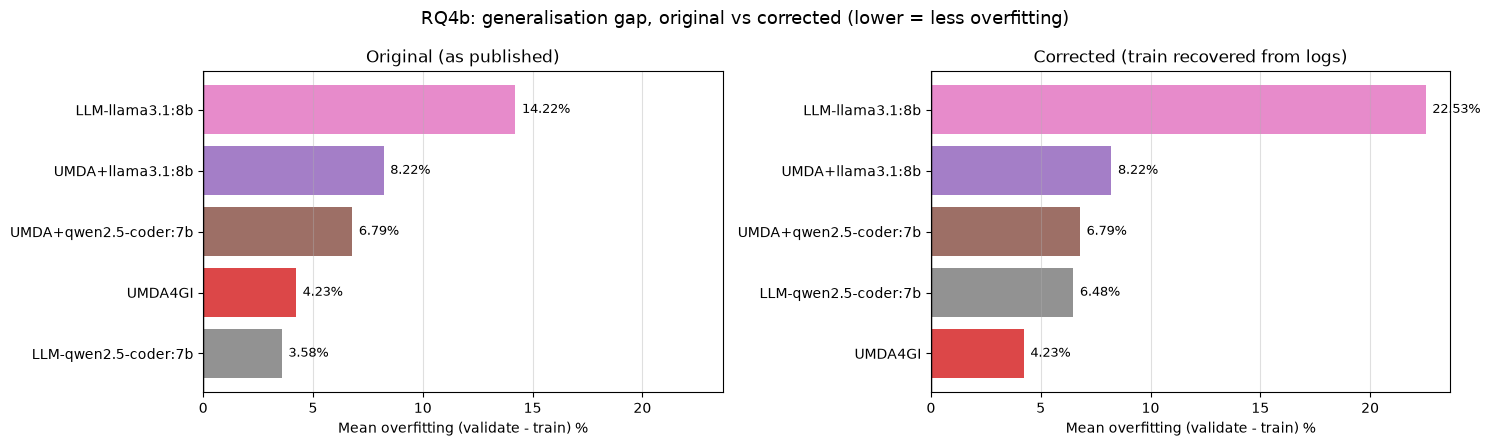

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharex=True)
for ax, (vals, title) in zip(axes, [(vals_ov_orig, 'Original (as published)'),
                                    (vals_ov_corr, 'Corrected (train recovered from logs)')]):
    s = vals['Mean'].sort_values()
    ax.barh(s.index, s.values, color=[color_map[g] for g in s.index], alpha=0.85)
    ax.axvline(0, color='k', linewidth=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Mean overfitting (validate - train) %')
    for i, val in enumerate(s.values):
        ax.text(val + 0.3, i, f'{val:.2f}%', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.4)
plt.suptitle('RQ4b: generalisation gap, original vs corrected (lower = less overfitting)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/RQ4b_overfit_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Validation improvement — must be unchanged

`change_perc_validate` is untouched by the bug (those 42 runs really were validated), so this
ranking is a control: it should come out **identical**. If it does not, something is wrong.

In [8]:
rank_val_orig, vals_val_orig = ranking(agg_orig, 'change_perc_validate')
rank_val_corr, vals_val_corr = ranking(agg_corr, 'change_perc_validate')

print('=== Rank per software (1 = most improvement) — ORIGINAL ===')
print(rank_val_orig.to_string())
print('\n=== ... CORRECTED ===')
print(rank_val_corr.to_string())
identical = rank_val_orig.equals(rank_val_corr)
print(f'\nIdentical: {identical}')
assert identical, 'validation ranking should not change'

=== Rank per software (1 = most improvement) — ORIGINAL ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA+qwen2.5-coder:7b           1.0       2.0    3.0   1.0   7.0
UMDA4GI                         3.0       1.0    2.0   3.0   9.0
UMDA+llama3.1:8b                4.0       3.0    1.0   2.0  10.0
LLM-qwen2.5-coder:7b            2.0       4.0    5.0   4.0  15.0
LLM-llama3.1:8b                 5.0       5.0    4.0   5.0  19.0

=== ... CORRECTED ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA+qwen2.5-coder:7b           1.0       2.0    3.0   1.0   7.0
UMDA4GI                         3.0       1.0    2.0   3.0   9.0
UMDA+llama3.1:8b                4.0       3.0    1.0   2.0  10.0
LLM-qwen2.5-coder:7b            2.0       4.0    5.0   4.0  15.0
LLM-llama3.1:8b                 5.0       5.0    4.0   5.0  19.0

Identi

## 3. Conclusions — does RQ4 still hold?

In [9]:
def verdict(rank_ov, label):
    s = rank_ov['Sum'].sort_values()
    worst = s.index[-1]
    best = s.index[0]
    print(f'--- {label} ---')
    print(f'  least overfitting : {best} (Sum={s.iloc[0]:.0f})')
    print(f'  most overfitting  : {worst} (Sum={s.iloc[-1]:.0f})')
    print('  full order        : ' + ' < '.join(f'{g} ({v:.0f})' for g, v in s.items()))
    print()

verdict(rank_ov_orig, 'ORIGINAL (what the paper reports)')
verdict(rank_ov_corr, 'CORRECTED')

print('Paper currently claims: "UMDA4GI and UMDA+qwen tie for the largest rank-sum (14 each)",')
print('i.e. the two UMDA-guided groups generalise worst of the five.')
print()
umda_sum = rank_ov_corr.loc['UMDA4GI', 'Sum']
uq_sum = rank_ov_corr.loc['UMDA+qwen2.5-coder:7b', 'Sum']
mx = rank_ov_corr['Sum'].max()
still = (umda_sum == mx) and (uq_sum == mx)
print(f'After correction: UMDA4GI={umda_sum:.0f}, UMDA+qwen={uq_sum:.0f}, max={mx:.0f}')
print(f'Claim still holds as written: {still}')

--- ORIGINAL (what the paper reports) ---
  least overfitting : UMDA+llama3.1:8b (Sum=10)
  most overfitting  : LLM-llama3.1:8b (Sum=16)
  full order        : UMDA+llama3.1:8b (10) < LLM-qwen2.5-coder:7b (10) < UMDA+qwen2.5-coder:7b (12) < UMDA4GI (12) < LLM-llama3.1:8b (16)

--- CORRECTED ---
  least overfitting : UMDA4GI (Sum=8)
  most overfitting  : LLM-llama3.1:8b (Sum=19)
  full order        : UMDA4GI (8) < UMDA+llama3.1:8b (9) < UMDA+qwen2.5-coder:7b (11) < LLM-qwen2.5-coder:7b (13) < LLM-llama3.1:8b (19)

Paper currently claims: "UMDA4GI and UMDA+qwen tie for the largest rank-sum (14 each)",
i.e. the two UMDA-guided groups generalise worst of the five.

After correction: UMDA4GI=8, UMDA+qwen=11, max=19
Claim still holds as written: False
